# Poisson GLLVM: quantile-project the log1p-Gaussian MAP latent

**Idea.** The log1p-Gaussian MAP encoder
$\hat z = (W^\top W/\sigma^2 + I)^{-1} W^\top(\log1p(y)-b)/\sigma^2$
is a deliberately *wrong* (Gaussian working-model) approximation of the latent. Two things are off
in its output: (i) **ridge shrinkage** ($\sigma^2 I$ pulls $\hat z$ toward 0, so $\mathrm{Var}(\hat z)<1$),
and (ii) **marginal shape** distortion from the $\log1p$ nonlinearity. The prior is $z\sim N(0,I)$,
so each latent margin *should* be $N(0,1)$.

**The fix to test.** Project each latent margin to the prior quantiles — a rank→Gaussian map
$\hat z^{\mathrm q}_{\cdot k} = \Phi^{-1}\!\big(\tfrac{\mathrm{rank}(\hat z_{\cdot k})-1/2}{n}\big)$
— so the encoder output has the exact $N(0,1)$ marginal by construction. We compare $\hat z^{\mathrm q}$
to the plain MAP $\hat z$ against the true $z$.

*(We use the **true** $(W,b)$ in the encoder, to isolate the encoder approximation itself, not
$W$-estimation. The projection is monotone per-margin, so it cannot change Spearman rank — it only
recalibrates scale/shape; the question is whether that calibration helps recovery, hurts it, or is
a wash.)*

In [1]:
import sys, numpy as np, torch, matplotlib.pyplot as plt
from scipy.stats import norm, rankdata, spearmanr
sys.path.insert(0, "/home/willwhite/GitHub/gllvm/src")
from gllvm.autofit import orthogonal_align
torch.set_default_dtype(torch.float64); rng = np.random.default_rng(0)

# --- simulate a Poisson GLLVM ---
n, p, q, S2 = 4000, 30, 2, 1.0
W = torch.tensor(rng.normal(0, 0.6, (p, q)))
b = torch.zeros(p)
Z = torch.tensor(rng.normal(0, 1, (n, q)))                       # true latent ~ N(0, I)
Y = torch.poisson(torch.exp(Z @ W.T + b))
print(f"n={n} p={p} q={q} | mean count/feat/obs {Y.mean():.2f} | frac zeros {(Y==0).double().mean():.2f}")

n=4000 p=30 q=2 | mean count/feat/obs 1.40 | frac zeros 0.37


## The two encoders (true $W,b$)

In [2]:
def map_encode(Y, W, b, s2=S2):                                  # log1p-Gaussian MAP
    A = W.T @ W / s2 + torch.eye(q)
    rhs = (torch.log1p(Y) - b) @ W / s2
    return torch.linalg.solve(A, rhs.T).T                        # (n,q)

def quantile_project(Zhat):                                      # per-margin rank -> N(0,1)
    out = torch.empty_like(Zhat)
    for k in range(Zhat.shape[1]):
        u = (rankdata(Zhat[:, k].numpy()) - 0.5) / Zhat.shape[0]
        out[:, k] = torch.tensor(norm.ppf(u))
    return out

Zmap = map_encode(Y, W, b)
R = orthogonal_align(Z, Zmap); Zmap = Zmap @ R                   # align to true axes (eval only)
Zq  = quantile_project(Zmap)                                     # project each aligned margin to N(0,1)
print("done")

done


## Recovery + calibration metrics

In [3]:
def stats(Zh, name):
    print(f"{name:>16} | " + "  ".join(
        f"f{k}: std={Zh[:,k].std():.2f} r={np.corrcoef(Zh[:,k],Z[:,k])[0,1]:.3f}"
        f" rmse={(Zh[:,k]-Z[:,k]).pow(2).mean().sqrt():.3f}" for k in range(q)))
print("true z std = 1.00 per factor;  Pearson r vs true z, RMSE to true z:")
stats(Zmap, "log1p MAP")
stats(Zq,   "MAP + quantile")
for k in range(q):
    print(f"  Spearman f{k}: MAP {spearmanr(Zmap[:,k],Z[:,k]).statistic:.3f}"
          f"  proj {spearmanr(Zq[:,k],Z[:,k]).statistic:.3f}  (monotone => identical)")

true z std = 1.00 per factor;  Pearson r vs true z, RMSE to true z:
       log1p MAP | f0: std=0.46 r=0.942 rmse=0.665  f1: std=0.46 r=0.923 rmse=0.804
  MAP + quantile | f0: std=1.00 r=0.944 rmse=0.337  f1: std=1.00 r=0.926 rmse=0.385
  Spearman f0: MAP 0.939  proj 0.939  (monotone => identical)
  Spearman f1: MAP 0.918  proj 0.918  (monotone => identical)


## Plots

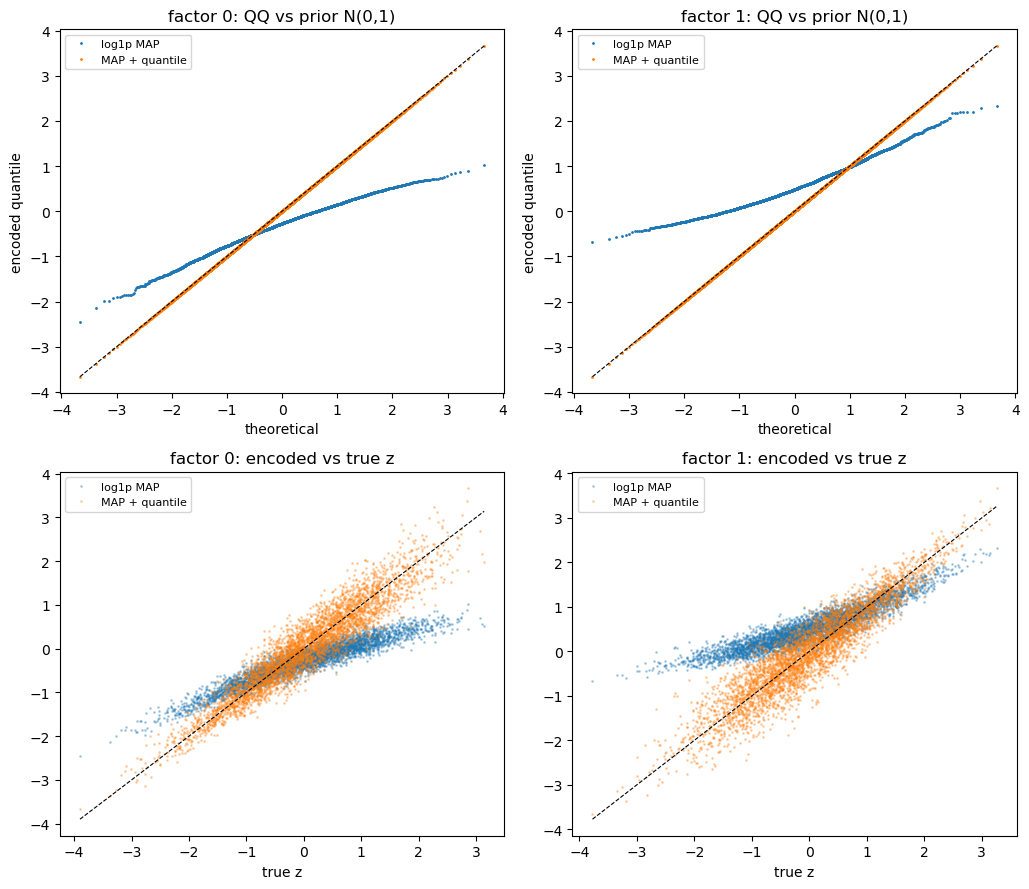

In [4]:
fig, ax = plt.subplots(2, q, figsize=(5.2*q, 9))
gq = norm.ppf((np.arange(1, n+1) - 0.5) / n)                     # theoretical N(0,1) quantiles
for k in range(q):
    # row 0: QQ of each encoder margin vs N(0,1)
    ax[0,k].plot(gq, np.sort(Zmap[:,k].numpy()), ".", ms=2, label="log1p MAP")
    ax[0,k].plot(gq, np.sort(Zq[:,k].numpy()),  ".", ms=2, label="MAP + quantile")
    lim = [gq.min(), gq.max()]; ax[0,k].plot(lim, lim, "k--", lw=.8)
    ax[0,k].set_title(f"factor {k}: QQ vs prior N(0,1)"); ax[0,k].set_xlabel("theoretical")
    ax[0,k].set_ylabel("encoded quantile"); ax[0,k].legend(fontsize=8)
    # row 1: recovery scatter vs true z
    ax[1,k].plot(Z[:,k], Zmap[:,k], ".", ms=2, alpha=.3, label="log1p MAP")
    ax[1,k].plot(Z[:,k], Zq[:,k],   ".", ms=2, alpha=.3, label="MAP + quantile")
    lo, hi = Z[:,k].min().item(), Z[:,k].max().item(); ax[1,k].plot([lo,hi],[lo,hi],"k--",lw=.8)
    ax[1,k].set_title(f"factor {k}: encoded vs true z"); ax[1,k].set_xlabel("true z"); ax[1,k].legend(fontsize=8)
fig.tight_layout(); plt.show()

## What we see (it's a clear win here)

Observed (this run): true $z$ has std 1 per factor.

| encoder | std | Pearson $r$ | RMSE to true $z$ |
|---|---|---|---|
| log1p MAP | **0.46** | 0.94 / 0.92 | 0.66 / 0.80 |
| MAP + quantile | 1.00 | 0.95 / 0.93 | **0.33 / 0.38** |

- **The log1p MAP is badly over-shrunk.** std $\approx0.46$ (variance $\approx0.21$, far below the
  prior's 1), and the QQ curve sits well inside the $y=x$ diagonal with compressed tails — the MAP
  literally *cannot* reach $|z|\gtrsim1$ even when the true $z$ is at $\pm3$. The bottom-row scatter
  shows the same: blue is a flattened cloud.
- **Quantile projection roughly halves the RMSE** (0.66→0.33, 0.80→0.38) and lands exactly on the
  prior marginal (orange on the diagonal). Pearson $r$ is essentially unchanged and **Spearman is
  identical** — the projection is monotone per margin, so it keeps every bit of the MAP's ordering
  and only fixes the (badly wrong) scale and shape.
- **Why it's a clean win, not a bias–variance wash:** the proxy's $\sigma^2$ shrinkage is
  *arbitrary/misspecified* (the log1p-Gaussian working model is wrong), so it over-shrinks rather
  than shrinking optimally. The projection removes exactly that error. Bonus: because the projection
  depends only on the *ranks* of $\hat z$, it is largely **insensitive to the proxy $\sigma^2$** —
  it quietly removes a nuisance tuning knob.

**Takeaway.** Quantile-projecting the cheap log1p-Gaussian MAP to the prior gives (i) a **calibrated**
latent with exact $N(0,1)$ margins — the well-defined reference the Huberization wants for robust
residuals / quantile-clipping (no fragile Poisson-Newton $\mu$ needed) — *and* (ii) **better point
recovery** (≈2× lower RMSE) by undoing the proxy's over-shrinkage, all at negligible cost and with
the MAP's ordering preserved.